In [1]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('OrdersandDeliveries.csv')
df.rename(columns={'Delivery Year ': 'Delivery Year'}, inplace=True)
df.dropna(subset=["Delivery Year"], inplace=True)
df.drop(labels=["Unfilled Orders"], axis=1, inplace=True)
df = df.reset_index(drop=True)
df.drop(index=len(df) - 1, inplace=True)
months = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6, "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10,
          "Nov": 11,
          "Dec": 12}
df.replace({"Order Month": months}, inplace=True)
df["Order Month Received"] = 12
df["Order Year"] = df["Order Year"].astype(int)
df["Delivery Year"] = df["Delivery Year"].astype(int)
df["Delivery Year"] = df["Delivery Year"].astype(int)
df = df[df["Order Total"] != "0"]
df["Order Total"] = df["Order Total"].astype(float)
df.dropna(inplace=True)

C:\Users\merda\AppData\Local\Temp\ipykernel_47892\2886073681.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Order Month": months}, inplace=True)


In [2]:
cols = ['Order Year', 'Order Month', 'Delivery Year', 'Order Month Received', 'Delivery Total', 'Order Total', 'Engine', 'Model Series', 'Region', 'Country', 'Customer Name']
df = df[cols]

In [3]:
dates_ordered = []
dates_received = []
for row in df.itertuples():
    dates_ordered.append(f'{row._1}-{row._2}-01')
for row in df.itertuples():
    dates_received.append(f'{row._3}-12-01')
df["Time Ordered"] = pd.to_datetime(dates_ordered)
df["Time Received"] = pd.to_datetime(dates_received)


In [4]:
df["Build Time"] = 0
for i, row in df.iterrows():
    df["Build Time"][i] = pd.date_range(df["Time Ordered"][i], df["Time Received"][i], freq='MS')
df = df.explode("Build Time")

C:\Users\merda\AppData\Local\Temp\ipykernel_47892\1885440167.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Build Time"][i] = pd.date_range(df["Time Ordered"][i], df["Time Received"][i], freq='MS')
C:\Users\merda\AppData\Local\Temp\

In [5]:

   import matplotlib.pyplot as plt
   import seaborn as sns
   assert "Build Time" in df.columns
   assert "Order Total" in df.columns
   assert "Model Series" in df.columns
   df["Build Time"] = pd.to_datetime(df["Build Time"], errors='coerce')
   df["Order Total"] = pd.to_numeric(df["Order Total"], errors='coerce')
   pip install --upgrade seaborn matplotlib


SyntaxError: invalid syntax (3130528821.py, line 8)

pandas.core.series.Series

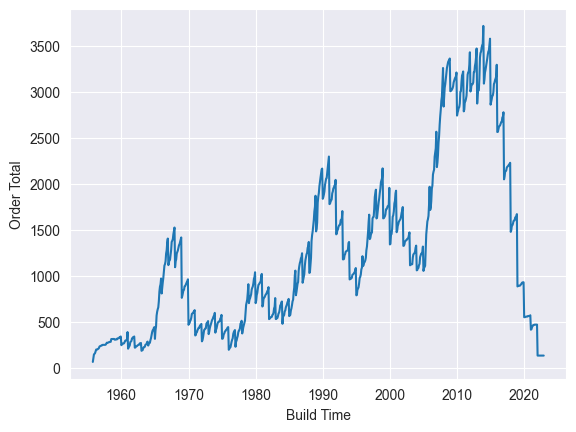

In [19]:
planes_per_month = df.groupby("Build Time")["Order Total"].sum()
sns.lineplot(planes_per_month)